In [15]:

from sklearn.datasets import make_blobs

from neuron import *


dimensions de X: (100, 2)
dimensions de y: (100, 1)


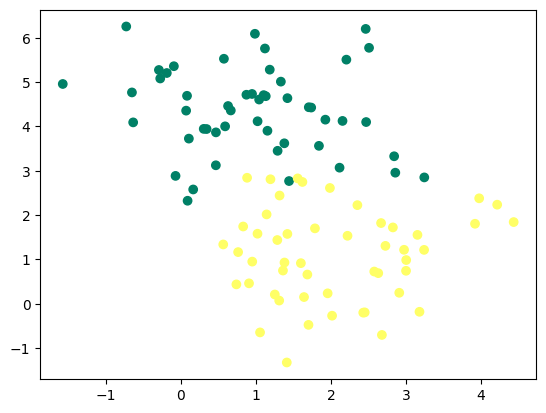

In [16]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

In [17]:
W,b = initialisation(X)
print(W.shape)
print(W)
print(b.shape)
print(b)


(2, 1)
[[0.71128849]
 [0.13933665]]
(1,)
[-1.09191364]


In [18]:
A = model(X,W,b)
print(A.shape)

(100, 1)


In [19]:
print(log_loss(A,y))

0.6905566179541391


In [20]:
dw,db = gradients(A,X,y)
print(dw.shape)
print(db.shape)

(2, 1)
()


None
None


100%|██████████| 100/100 [00:00<00:00, 19167.83it/s]


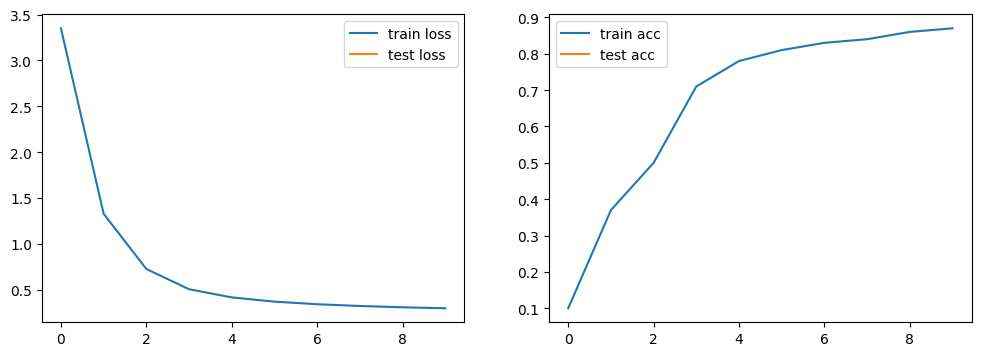

In [21]:
W,b = artificial_neuron(X,y)

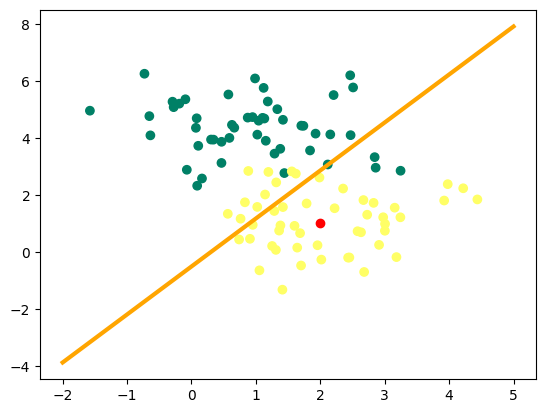

[ True]


In [22]:
new_plant = np.array([2,1])

x0 = np.linspace(-2,5,100)
x1 = (-W[0] * x0 - b) / W[1]

plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.scatter(new_plant[0],new_plant[1],c='r')
plt.plot(x0,x1,c="orange",lw=3)

plt.show()
print(predict(new_plant,W,b))


In [23]:
import plotly.graph_objects as go

In [24]:
fig = go.Figure(data=[go.Scatter3d(
    x = X[:,0].flatten(),
    y = X[:,1].flatten(),
    z = y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity = 0.8,
        reversescale=True
    )
    
)])

fig.update_layout(template="plotly_dark", margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type = "orthographic"
fig.show()

In [25]:
X0 = np.linspace(X[:,0].min(),X[:,0].max(),100)
X1 = np.linspace(X[:,1].min(),X[:,1].max(),100)
xx0,xx1 = np.meshgrid(X0,X1)
Z = W[0] * xx0 + W[1] * xx1 + b
A = 1 / (1 + np.exp(-Z))

fig = (go.Figure(data=[go.Surface(z=A,x=xx0,y=xx1,colorscale='YlGn',opacity = 0.7,reversescale=True)]))

fig.add_scatter3d(
    x = X[:,0].flatten(),
    y = X[:,1].flatten(),
    z = y.flatten(),
    mode='markers',
    marker=dict(
        size=5,
        color=y.flatten(),
        colorscale='YlGn',
        opacity = 0.8,
        reversescale=True
    ))

fig.update_layout(template="plotly_dark", margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type = "orthographic"
fig.show()